In [7]:
#FashionMNIST grid model
#不变动位置

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
import numpy as np

california_housing = fetch_california_housing(data_home='./data')
X, y = california_housing.data, california_housing.target

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

class CaliforniaHousingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx].unsqueeze(0)

train_dataset = CaliforniaHousingDataset(X_train_scaled, y_train)
val_dataset = CaliforniaHousingDataset(X_val_scaled, y_val)
test_dataset = CaliforniaHousingDataset(X_test_scaled, y_test)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

for x,y in train_loader:
    print(x.shape)
    print(y.shape)
    break

y_batch = torch.tensor([1.2, 2.3, 3.4])
print(y_batch.shape)
y_batch_unsqueezed = y_batch.unsqueeze(1)  
print(y_batch_unsqueezed.shape)
print(y_batch_unsqueezed)


14448
3096
3096
torch.Size([64, 8])
torch.Size([64, 1])
torch.Size([3])
torch.Size([3, 1])
tensor([[1.2000],
        [2.3000],
        [3.4000]])


In [8]:
class HousePrice(nn.Module):
    def __init__(self,input_size,output_size = 1,hidden_size = 30):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x
    
input_size = X.shape[1]
model = HousePrice(input_size=input_size)

print(model)


HousePrice(
  (fc1): Linear(in_features=8, out_features=30, bias=True)
  (fc2): Linear(in_features=30, out_features=1, bias=True)
  (relu): ReLU()
)


using device: cuda
using lr: 0.1
[Step 50] Val Loss: 0.4863
[Step 100] Val Loss: 0.4679
[Step 150] Val Loss: 0.4524
[Step 200] Val Loss: 0.4968
Epoch [1/100]  Train Loss: 0.7707
[Step 250] Val Loss: 0.4436
[Step 300] Val Loss: 0.5919
[Step 350] Val Loss: 0.7522
[Step 400] Val Loss: 0.5070
[Step 450] Val Loss: 0.6688
Epoch [2/100]  Train Loss: 2.4661
[Step 500] Val Loss: 0.4524
[Step 550] Val Loss: 0.4523
[Step 600] Val Loss: 0.4995
[Step 650] Val Loss: 0.4224
Epoch [3/100]  Train Loss: 0.9059
[Step 700] Val Loss: 0.4287
[Step 750] Val Loss: 0.5307
[Step 800] Val Loss: 0.4462
[Step 850] Val Loss: 0.5053
[Step 900] Val Loss: 0.5000
Epoch [4/100]  Train Loss: 2.3160
[Step 950] Val Loss: 0.4378
[Step 1000] Val Loss: 0.4264
[Step 1050] Val Loss: 0.4115
[Step 1100] Val Loss: 0.5833
Epoch [5/100]  Train Loss: 0.4373
[Step 1150] Val Loss: 0.4725
[Step 1200] Val Loss: 0.5808
[Step 1250] Val Loss: 0.4075
[Step 1300] Val Loss: 0.3894
[Step 1350] Val Loss: 0.4057
Epoch [6/100]  Train Loss: 0.4519


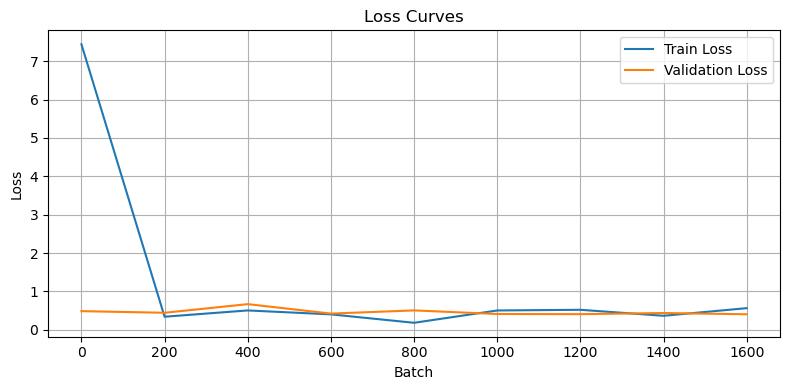

average_test_loss: 0.3661
using lr: 0.01
[Step 50] Val Loss: 0.7097
[Step 100] Val Loss: 0.5145
[Step 150] Val Loss: 0.4637
[Step 200] Val Loss: 0.4504
Epoch [1/100]  Train Loss: 0.7547
[Step 250] Val Loss: 0.4452
[Step 300] Val Loss: 0.4240
[Step 350] Val Loss: 0.4279
[Step 400] Val Loss: 0.4299
[Step 450] Val Loss: 0.4302
Epoch [2/100]  Train Loss: 0.4299
[Step 500] Val Loss: 0.4187
[Step 550] Val Loss: 0.4119
[Step 600] Val Loss: 0.3993
[Step 650] Val Loss: 0.4054
Epoch [3/100]  Train Loss: 0.4223
[Step 700] Val Loss: 0.4172
[Step 750] Val Loss: 0.3842
[Step 800] Val Loss: 0.3840
[Step 850] Val Loss: 0.3759
[Step 900] Val Loss: 0.4019
Epoch [4/100]  Train Loss: 0.3803
[Step 950] Val Loss: 0.3842
[Step 1000] Val Loss: 0.3620
[Step 1050] Val Loss: 0.4056
[Step 1100] Val Loss: 0.3685
Epoch [5/100]  Train Loss: 0.3609
[Step 1150] Val Loss: 0.3849
[Step 1200] Val Loss: 0.3672
[Step 1250] Val Loss: 0.3712
[Step 1300] Val Loss: 0.3628
[Step 1350] Val Loss: 0.3563
Epoch [6/100]  Train Loss:

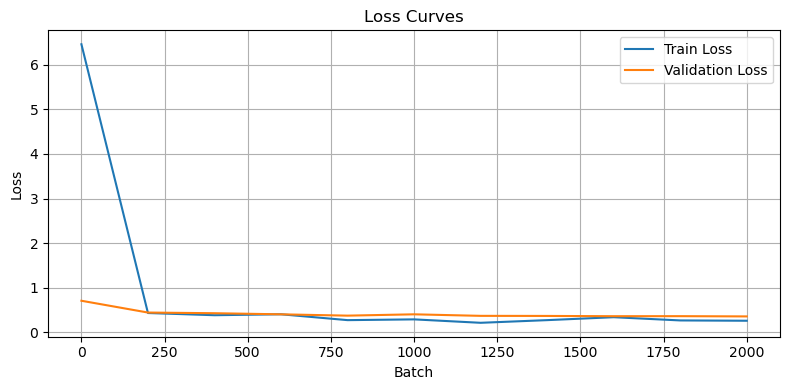

average_test_loss: 0.3198
using lr: 0.001
[Step 50] Val Loss: 5.0239
[Step 100] Val Loss: 3.3087
[Step 150] Val Loss: 2.0448
[Step 200] Val Loss: 1.2567
Epoch [1/100]  Train Loss: 3.3474
[Step 250] Val Loss: 0.9220
[Step 300] Val Loss: 0.8214
[Step 350] Val Loss: 0.7728
[Step 400] Val Loss: 0.7349
[Step 450] Val Loss: 0.7021
Epoch [2/100]  Train Loss: 0.8077
[Step 500] Val Loss: 0.6717
[Step 550] Val Loss: 0.6426
[Step 600] Val Loss: 0.6164
[Step 650] Val Loss: 0.5937
Epoch [3/100]  Train Loss: 0.6234
[Step 700] Val Loss: 0.5733
[Step 750] Val Loss: 0.5550
[Step 800] Val Loss: 0.5372
[Step 850] Val Loss: 0.5232
[Step 900] Val Loss: 0.5092
Epoch [4/100]  Train Loss: 0.5299
[Step 950] Val Loss: 0.4999
[Step 1000] Val Loss: 0.4902
[Step 1050] Val Loss: 0.4834
[Step 1100] Val Loss: 0.4758
Epoch [5/100]  Train Loss: 0.4763
[Step 1150] Val Loss: 0.4703
[Step 1200] Val Loss: 0.4647
[Step 1250] Val Loss: 0.4621
[Step 1300] Val Loss: 0.4584
[Step 1350] Val Loss: 0.4554
Epoch [6/100]  Train Loss

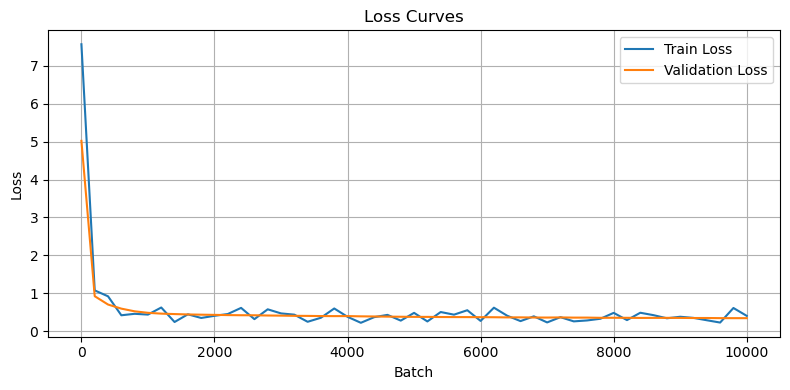

average_test_loss: 0.3131
using lr: 0.0001
[Step 50] Val Loss: 5.2469
[Step 100] Val Loss: 5.0540
[Step 150] Val Loss: 4.8672
[Step 200] Val Loss: 4.6953
Epoch [1/100]  Train Loss: 5.0669
[Step 250] Val Loss: 4.5204
[Step 300] Val Loss: 4.3550
[Step 350] Val Loss: 4.1838
[Step 400] Val Loss: 4.0187
[Step 450] Val Loss: 3.8584
Epoch [2/100]  Train Loss: 4.2661
[Step 500] Val Loss: 3.7008
[Step 550] Val Loss: 3.5474
[Step 600] Val Loss: 3.3929
[Step 650] Val Loss: 3.2504
Epoch [3/100]  Train Loss: 3.5473
[Step 700] Val Loss: 3.1184
[Step 750] Val Loss: 2.9832
[Step 800] Val Loss: 2.8538
[Step 850] Val Loss: 2.7256
[Step 900] Val Loss: 2.5999
Epoch [4/100]  Train Loss: 2.9163
[Step 950] Val Loss: 2.4806
[Step 1000] Val Loss: 2.3638
[Step 1050] Val Loss: 2.2562
[Step 1100] Val Loss: 2.1575
Epoch [5/100]  Train Loss: 2.3823
[Step 1150] Val Loss: 2.0636
[Step 1200] Val Loss: 1.9750
[Step 1250] Val Loss: 1.8893
[Step 1300] Val Loss: 1.8065
[Step 1350] Val Loss: 1.7278
Epoch [6/100]  Train Los

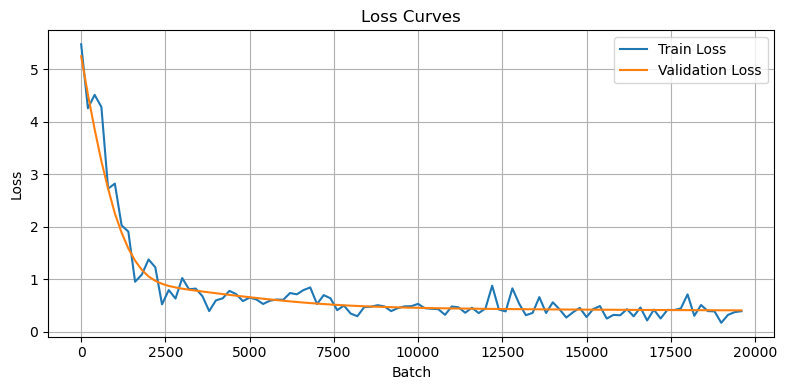

average_test_loss: 0.3837


In [10]:
from my_trainer import Trainer,EarlyStopping,ModelCheckpoint

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using device: {device}")
for lr in [1e-1, 1e-2, 1e-3, 1e-4]:
    print(f"using lr: {lr}")
    
    model = HousePrice(input_size=input_size).to(device)
    
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    early_stopping = EarlyStopping(patience=10, min_delta=0.001, mode='min')
    
    model_checkpoint = ModelCheckpoint(
        filepath="./checkpoints/regression_model_epoch_{epoch}.ckpt",
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        min_delta=0.001
    )
    
    trainer = Trainer(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        early_stopping=early_stopping,
        model_checkpoint=model_checkpoint,
        train_loader=train_loader,
        val_loader=val_loader,
        eval_step=50
    )
    
    trainer.train_regression(num_epochs=100)
    trainer.plot_curves(200)
    
    model.eval()
    test_loss = 0.0
    total = 0
    with torch.no_grad():
        for batch in test_loader:
            x, y = batch
            x, y = x.to(device), y.to(device)
            y_pred = model(x)
            loss = criterion(y_pred, y)
            test_loss += loss.item() * x.size(0)
            total += x.size(0)
        avg_test_loss = test_loss / total if total > 0 else 0
        print(f"average_test_loss: {avg_test_loss:.4f}")
